# Statistical Analysis for the Echoes of Humanity Paper

## Imports and Plot Configs

In [19]:
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [20]:
# 3.3 polegadas de largura, 1.65 * isso (golden ratio) altura
plt.rcParams['figure.figsize'] = (3.3, 3.3  / 1.65)

plt.rcParams['axes.axisbelow'] = True
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.ymargin'] = 0.1

plt.rcParams['font.family'] = 'serif'

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = 'lightgrey'
plt.rcParams['grid.linewidth'] = .1

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['xtick.bottom'] = True
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['xtick.minor.width'] = .5
plt.rcParams['xtick.minor.visible'] = True

plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['ytick.minor.width'] = .5
plt.rcParams['ytick.minor.visible'] = True

plt.rcParams['legend.fontsize'] = 12

plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 5

## Initial Section on Good Answers

In [21]:
df = pd.read_csv('answers-july03rd/raw-answers-jul30.csv', index_col=1)
df = df.drop('Unnamed: 0', axis='columns')
df['uuid_order'] = df.groupby('uuid').cumcount() + 1
len(set(df['uuid']))

653

In [22]:
df

,uuid,track_A,track_B,human_perception,comments,is_last_response,time_spent,timestamp,song_recognition,uuid_order
id,,,,,,,,,,
9f8771eb-3afc-4554-85ef-dd3b62c66b66,deeab0e6-ad56-4510-95f4-897464951a82,audios/random/emkwtysd.mp3,audios/random/rycsunu2.mp3,NaN,NaN,False,NaN,2025-06-10 00:43:36.981286,NaN,1
1662145b-7247-4d7d-a291-3de5d6c111c9,deeab0e6-ad56-4510-95f4-897464951a82,audios/rq1/par7/znxd2wka.mp3,audios/rq1/par7/2dyp2m8k.mp3,NaN,NaN,False,NaN,2025-06-10 00:43:36.981286,NaN,2
8604136e-c9af-43b9-97f2-c0d5ceafb84a,deeab0e6-ad56-4510-95f4-897464951a82,audios/rq1/par6/6sdqefhc.mp3,audios/rq1/par6/l11vtp2a.mp3,NaN,NaN,False,NaN,2025-06-10 00:43:36.981286,NaN,3
3ae53ca2-0ed2-432f-8fbc-13c3c9e2321e,deeab0e6-ad56-4510-95f4-897464951a82,audios/random/xxzmx3db.mp3,audios/random/ps97lti8.mp3,NaN,NaN,False,NaN,2025-06-10 00:43:36.981286,NaN,4
eafea70c-faf1-44b7-b47f-a8dedb3728d9,deeab0e6-ad56-4510-95f4-897464951a82,audios/default-pair/default.mp3,audios/default-pair/default1.mp3,NaN,NaN,False,NaN,2025-06-10 00:43:36.981286,NaN,5
...,...,...,...,...,...,...,...,...,...,...
602767b5-a20c-48b1-a1fd-640235b1f9ec,38bf2a5c-763b-4978-adc9-b6608d5b270b,audios/rq1/par4/jfxaxuvc.mp3,audios/rq1/par4/amsg72l5.mp3,2.0,NaN,False,234568.0,2025-06-20 06:39:48.530307,0.0,1
510856e3-9e4e-4807-acc5-0e10253373e7,38bf2a5c-763b-4978-adc9-b6608d5b270b,audios/random/rycsunu2.mp3,audios/random/emkwtysd.mp3,0.0,NaN,False,183926.0,2025-06-20 06:39:48.530307,0.0,2
747976a8-9a2b-4d7b-ba8b-6d8c4d0bed51,38bf2a5c-763b-4978-adc9-b6608d5b270b,audios/rq1/par9/bzwu2027.mp3,audios/rq1/par9/0pce8u6v.mp3,3.0,NaN,False,138730.0,2025-06-20 06:39:48.530307,0.0,3


In [23]:
did_last = df[
    (df.track_A.str.contains('default')) &
    (~df['human_perception'].isna())
]
did_last.shape

(504, 10)

In [24]:
(did_last['human_perception'] == 1.0).mean()

np.float64(0.7400793650793651)

In [25]:
len(set(df[df.track_A.str.contains('default')].dropna()['uuid']))

152

In [26]:
df[df.track_A.str.contains('default')]

,uuid,track_A,track_B,human_perception,comments,is_last_response,time_spent,timestamp,song_recognition,uuid_order
id,,,,,,,,,,
eafea70c-faf1-44b7-b47f-a8dedb3728d9,deeab0e6-ad56-4510-95f4-897464951a82,audios/default-pair/default.mp3,audios/default-pair/default1.mp3,NaN,NaN,False,NaN,2025-06-10 00:43:36.981286,NaN,5
3a0bc131-1124-4a06-851e-8fcb70fccfde,28e643ea-6a54-4fcd-9282-13a196be7e36,audios/default-pair/default.mp3,audios/default-pair/default1.mp3,1.0,NaN,False,252652.0,2025-06-10 00:43:36.981286,2.0,5
62612828-8103-4520-9d8f-e95b2c759125,5d2ca4a5-b72f-4045-b5bd-955f5b506adf,audios/default-pair/default.mp3,audios/default-pair/default1.mp3,1.0,NaN,False,69413.0,2025-06-10 00:43:36.982645,2.0,5
e971ea32-1a5a-4891-8ef2-e9f116a1e6b9,00a8319b-9b19-42f5-8767-e004a03dab40,audios/default-pair/default.mp3,audios/default-pair/default1.mp3,1.0,Track 1 – AI\n- Because of the lyrics.\n\nTrac...,False,283251.0,2025-06-10 00:43:36.983567,2.0,5
9456592c-f4d1-4826-86ef-aa53bd7c0414,edc85231-b42c-4cc9-ac8d-c4b55cdcf75b,audios/default-pair/default.mp3,audios/default-pair/default1.mp3,1.0,NaN,True,73018.0,2025-06-10 00:43:36.981286,2.0,5
...,...,...,...,...,...,...,...,...,...,...
20ab7400-68ca-409e-bcc6-9032b14319ad,41eda92b-f5e9-43c9-96fd-571d78022bca,audios/default-pair/default.mp3,audios/default-pair/default1.mp3,1.0,NaN,False,327395.0,2025-06-20 06:39:48.530307,2.0,5
bf1b3bdc-3576-4fcd-8b26-01567d9bf80d,186a30fa-3858-4258-a7fe-f0c248a171a5,audios/default-pair/default.mp3,audios/default-pair/default1.mp3,1.0,NaN,False,56250.0,2025-06-20 06:39:48.530307,2.0,5
1f90f37f-db1d-44e2-a545-549929f6fec6,17c5df91-ef59-4149-8366-aec7c5d6e24a,audios/default-pair/default.mp3,audios/default-pair/default1.mp3,NaN,NaN,False,NaN,2025-06-20 06:39:48.518002,NaN,1


In [27]:
good = df[
    (df.track_A.str.contains('default')) & # did the 5th
    (df['human_perception'] == 1.0) &      # got it right
    (df['song_recognition'] == 2.0)        # knew beethoven
]['uuid']
df_answer = df[(df['uuid'].isin(good))]
len(set(good))

337

In [28]:
df_answer = df_answer[df_answer['song_recognition'] == 0.0]
len(set(df_answer['uuid']))

334

In [29]:
uuids_n = df_answer.groupby('uuid').size()
good = uuids_n[uuids_n == 4].index
df_answer = df_answer[(df_answer['uuid'].isin(good))]
len(set(df_answer['uuid']))

308

In [30]:
len(set(df_answer[~pd.isna(df_answer['comments'])]['uuid']))

145

In [31]:
df_answer[~pd.isna(df_answer['comments'])].shape

(332, 10)

## Demographic Plots

In [32]:
good = df_answer['uuid'].unique()
df_user = pd.read_csv('answers-july03rd/raw-users-jul30.csv')
df_user = df_user.drop('Unnamed: 0', axis='columns')
df_user = df_user.dropna()
df_user = df_user[df_user['uuid'].isin(good)]
df_user

,uuid,language,age,practical_experience,formal_experience,knows_ai_music
0,f7e445e4-3932-4d78-8fa3-9e048c3d93f8,portuguese,28.0,3.0,0.0,False
3,4d0a7e46-f950-45f3-bb1c-8f151c552492,portuguese,19.0,1.0,0.0,False
4,07df4321-2911-4325-baca-b7354cc64ed2,portuguese,24.0,3.0,1.0,True
5,a7cccb49-bcc9-41b5-bced-abd9cfaeb9a6,portuguese,20.0,0.0,0.0,True
7,93258826-c68e-450a-88ab-67f22d26b3c7,portuguese,20.0,0.0,1.0,False
...,...,...,...,...,...,...
676,353481ae-70bb-422e-abec-8c530a949f37,mandarin,18.0,2.0,1.0,True
677,98e54764-81a7-4190-96f9-6bff6038a7eb,portuguese,19.0,1.0,0.0,False
678,41eda92b-f5e9-43c9-96fd-571d78022bca,portuguese,57.0,0.0,0.0,False
679,186a30fa-3858-4258-a7fe-f0c248a171a5,portuguese,16.0,3.0,3.0,True


In [33]:
experience_trans = {
    0.0: 'a. [0, 1y)',
    1.0: 'b. [1-5y)',
    2.0: 'c. [5-10y)',
    3.0: 'd. [10y, )'
}

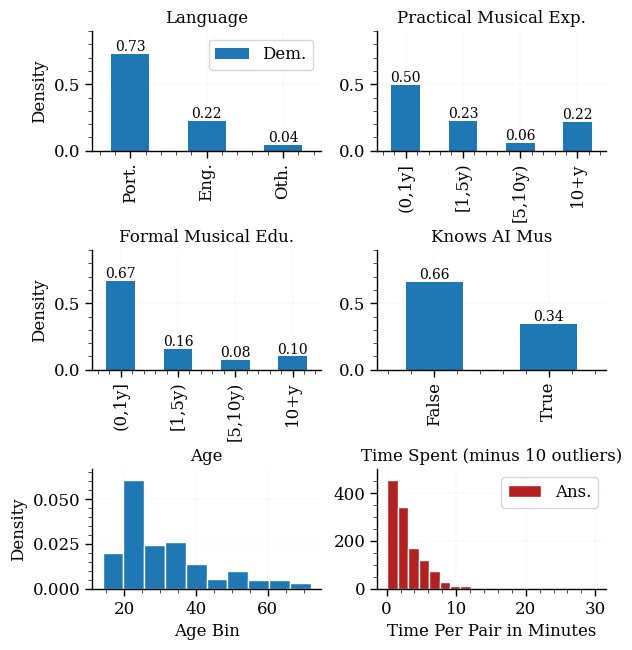

In [61]:
fig, axes = plt.subplots(3, 2, figsize=(6, 6 * (1.61 * 2/3)))
axes = axes.ravel()

df_user['lang_plot'] = 'Oth.'
df_user.loc[
    df_user['language'] == 'portuguese', 'lang_plot'
] = 'Port.'
df_user.loc[
    df_user['language'] == 'english', 'lang_plot'
] = 'Eng.'

(df_user['lang_plot'].
 value_counts(normalize=True).
 plot.bar(ax=axes[0], label='Dem.')
)


(df_user['practical_experience'].
 map(experience_trans).
 value_counts(normalize=True).
 sort_index().
 plot.bar(ax=axes[1], label='Dem.')
)

(df_user['formal_experience'].
 map(experience_trans).
 value_counts(normalize=True).
 sort_index().
 plot.bar(ax=axes[2], label='Dem.')
)

(df_user['age'].
 plot.hist(edgecolor='w', ax=axes[4], density=True, label='Dem.')
)

(df_user['knows_ai_music'].
 value_counts(normalize=True).
 sort_index().
 plot.bar(ax=axes[3], label='Dem.')
)

for i in [0, 1, 2, 3]:
    axes[i].set(
        ylim=(0, 0.9)
    )
for i in [0, 1, 2, 3, 4]:
    axes[i].set_xlabel(None)
axes[0].set_ylabel('Density')
axes[2].set_ylabel('Density')
axes[4].set_ylabel('Density')

axes[4].set_xlabel('Age Bin')

axes[0].set_title('Language')
axes[1].set_title('Practical Musical Exp.')
axes[2].set_title('Formal Musical Edu.')
axes[3].set_title('Knows AI Mus')
axes[4].set_title('Age')


import matplotlib.ticker as mtick
for ax in axes[:4]:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

new_x_labels = ['(0,1y]', '[1,5y)', '[5,10y)', '10+y']
axes[1].set_xticklabels(new_x_labels)
axes[2].set_xticklabels(new_x_labels)



((df_answer[['time_spent']]  / (1000 * 60)).
 sort_values(by='time_spent').iloc[:-5].
 rename(columns={'time_spent': 'Ans.'}).
 plot.hist(edgecolor='w', bins=20,  ax=axes[-1], color='firebrick'))

for ax in axes:
    # ax.tick_params(axis='x', labelrotation=75) 
    sns.despine(ax=ax)

axes[5].set_title('Time Spent (minus 10 outliers)')
axes[5].set_ylabel(None)
axes[5].set_xlabel('Time Per Pair in Minutes')


axes[0].legend()
axes[-1].legend()

fig.tight_layout(pad=0.5)

plt.savefig('users-t.pdf',bbox_inches='tight')

In [35]:
((df_answer[['time_spent']]  / (1000 * 60)).
 sort_values(by='time_spent').iloc[:-10]).describe()

,time_spent
count,1222.000000
mean,2.981275
std,2.508626
min,0.110733
25%,1.226458
50%,2.190925
75%,4.156842
max,18.457933


<Axes: ylabel='Frequency'>

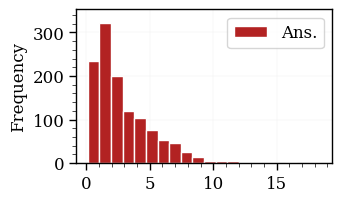

In [36]:
((df_answer[['time_spent']]  / (1000 * 60)).
 sort_values(by='time_spent').iloc[:-10].
 rename(columns={'time_spent': 'Ans.'}).
 plot.hist(edgecolor='w', bins=20, color='firebrick'))

In [37]:
df_user['age'].describe()

count    290.000000
mean      31.113793
std       12.765010
min       14.000000
25%       21.000000
50%       27.000000
75%       37.000000
max       72.000000
Name: age, dtype: float64

## Create a DataFrame where a is always the correct answer

In [38]:
def get_strd_df(df_answer):
    df_answer = df_answer.copy()
    data = {
        "Code": [0.0, 1.0, 2.0, 3.0, 4.0],
        "Meaning": [
            "neither",
            "a_ai",
            "b_ai",
            "both",
            "undecided"
        ]
    }
    
    df_code = pd.DataFrame(data).set_index('Code')['Meaning']

    df_songs = pd.read_csv('answers-july03rd/raw-songs-jul-3rd.csv')
    aiorh = df_songs[['name', 'type']].set_index('name')['type']

    df_answer.loc[:, 'resp'] = df_answer['human_perception'].map(df_code)
    df_answer.loc[:, 'a_type'] = df_answer['track_A'].map(aiorh)
    df_answer.loc[:, 'b_type'] = df_answer['track_B'].map(aiorh)

    df_a_ai = df_answer[df_answer['a_type'] == 'genai'].copy()
    df_b_ai = df_answer[df_answer['b_type'] == 'genai'].copy()

    # swap tracks so that A is always AI
    aux = df_b_ai['track_B'].copy()
    df_b_ai.loc[:, 'track_B'] = df_b_ai['track_A']
    df_b_ai.loc[:, 'track_A'] = aux
    
    # swap answers
    df_b_ai.loc[:, 'resp'] = df_b_ai['resp'].str.replace('a_ai', 'aux')
    df_b_ai.loc[:, 'resp'] = df_b_ai['resp'].str.replace('b_ai', 'a_ai')
    df_b_ai.loc[:, 'resp'] = df_b_ai['resp'].str.replace('aux', 'b_ai')
    
    df_b_ai.loc[:, 'a_type'] = 'genai'
    df_b_ai.loc[:, 'b_type'] = 'human'
    
    df_answer_strd = pd.concat((df_a_ai, df_b_ai))

    track_A_f = (df_answer_strd['track_A'].
             str.split('/', expand=True)[[2, 3]].T.
             ffill().T[[3]].
             rename(columns={3: 'track_A_f'})
    )

    track_B_f = (df_answer_strd['track_B'].
                 str.split('/', expand=True)[[2, 3]].T.
                 ffill().T[[3]].
                 rename(columns={3: 'track_B_f'})
    )
    
    df_answer_strd = pd.concat(
        (df_answer_strd, track_A_f, track_B_f),
        axis='columns'
    )
    return df_answer_strd

In [39]:
df_answer_strd = get_strd_df(df_answer)

## Simple Binomial Tests

In [40]:
def fraction(df, decided_only=True):
    from scipy.stats import binomtest
    df = df.copy()
    if decided_only:
        df = df[df['resp'].isin(['b_ai', 'a_ai'])]
    correct = 0
    correct += df[
        (df['resp'] == 'a_ai') & (df['a_type'] == 'genai')
    ].shape[0]
    # correct += df[
    #     (df['resp'] == 'b_ai') & (df['b_type'] == 'genai')
    # ].shape[0]
    if decided_only:
        p = 0.5
    else:
        p = 1 / 5
    return binomtest(
        correct,
        n = df.shape[0],
        p = p
    )

In [41]:
def general_exp(df, decided_only=True):
    print('CI overall')
    print(fraction(df, decided_only))
    print()

    print('CI rand')
    print(fraction(df[df['track_A'].str.contains('random')], decided_only))
    print()

    print('CI rq1')
    print(fraction(df[df['track_A'].str.contains('rq1')], decided_only))
    print()

In [42]:
general_exp(df_answer_strd)

CI overall
BinomTestResult(k=428, n=711, alternative='two-sided', statistic=0.6019690576652602, pvalue=6.009485732299534e-08)

CI rand
BinomTestResult(k=192, n=358, alternative='two-sided', statistic=0.5363128491620112, pvalue=0.1863281047818784)

CI rq1
BinomTestResult(k=236, n=353, alternative='two-sided', statistic=0.6685552407932012, pvalue=2.298470507446033e-10)



In [43]:
general_exp(df_answer_strd, False)

CI overall
BinomTestResult(k=428, n=1232, alternative='two-sided', statistic=0.3474025974025974, pvalue=1.733068280804316e-33)

CI rand
BinomTestResult(k=192, n=616, alternative='two-sided', statistic=0.3116883116883117, pvalue=5.7671001184388855e-11)

CI rq1
BinomTestResult(k=236, n=616, alternative='two-sided', statistic=0.38311688311688313, pvalue=1.4643035585060045e-25)



## Create the Bambi Dataframe

In [44]:
def create_bambi(df_answer_strd):
    df_answer_strd = df_answer_strd.copy()
    df_causal = (df_answer_strd.reset_index().merge(
        df_user,
        left_on='uuid',
        right_on='uuid'
    )[['id', 'uuid', 'uuid_order', 'time_spent', 'language', 'age',
       'practical_experience', 'formal_experience',
       'knows_ai_music', 'resp']].
                 set_index('id').
                 sort_index().
                 copy()
    )
    
    df_causal.loc[
        :, 'choice_type'
    ] = 0.0
    df_causal.loc[
        df_causal['resp'].isin(['a_ai', 'b_ai']), 'choice_type'
    ] = 1
    df_causal.loc[
        df_causal['resp'].isin(['neither']), 'choice_type'
    ] = 2
    df_causal.loc[
        df_causal['resp'].isin(['both']), 'choice_type'
    ] = 3
    
    # df_causal['made_choice'] = df_causal['resp'].isin(['a_ai', 'b_ai']).astype(int)
    # df_causal = df_causal[
    #     df_causal['uuid'].isin(
    #         df_user[df_user['language'] == 'english']['uuid']
    #     )
    # ]
    df_causal.loc[:, 'is_pt'] = (df_causal['language'] == 'portuguese')
    df_causal.loc[:, 'y'] = (df_causal['resp'] == 'a_ai').astype(int)
    df_causal.loc[:, 't'] = df_answer_strd['track_B'].str.contains('rq1').astype(int)
    df_causal.loc[:, 'time_spent'] = np.log10(df_causal['time_spent'] + 1)
    df_causal = df_causal.drop(['language', 'resp'], axis='columns')

    return df_causal
df_causal = create_bambi(df_answer_strd)

In [45]:
df_causal

,uuid,uuid_order,time_spent,age,practical_experience,formal_experience,knows_ai_music,choice_type,is_pt,y,t
id,,,,,,,,,,,
0010dca0-3391-480c-bd3a-bbbbfbf0e4b8,b25cbbda-77b2-4a69-9fdb-ab201bcbe409,4,5.994484,25.0,0.0,0.0,False,2.0,True,0,1
002ce034-547c-45f2-ad95-a6fcc095f8d6,b9839342-fa62-4ae9-978e-99977cdde4ba,3,4.924398,20.0,3.0,2.0,True,1.0,True,1,0
007226c9-5c73-448a-8e78-d063f589426f,5ff34178-ba2f-4758-ae04-dbfdd1da9433,4,4.702732,38.0,3.0,3.0,True,1.0,False,1,1
011e5731-9e75-48f9-bb1f-c6903097607f,e815058b-50b6-4b78-9eab-2a15d859fcd8,2,4.905224,22.0,0.0,0.0,False,1.0,True,1,1
014927f4-b6c5-4824-bd05-65b74182e30e,9fcbe62d-71f4-410e-a699-5b568acf92d0,4,4.802158,22.0,0.0,0.0,True,2.0,True,0,0
...,...,...,...,...,...,...,...,...,...,...,...
ff94217f-3575-4bda-bbe2-efbe077d08f7,3d08b4c2-dd62-4766-b9f9-8e843822cfb0,4,6.028577,46.0,0.0,0.0,True,3.0,True,0,0
ffad128d-3a58-444d-8100-47f2e8ec68b4,0f65292a-52f3-4310-adb0-1f1b82922d66,3,4.939879,19.0,1.0,0.0,True,1.0,True,1,0
ffc86a19-2dd6-4fc5-a5d9-e2ba60fd3b75,186a30fa-3858-4258-a7fe-f0c248a171a5,3,5.211852,16.0,3.0,3.0,True,1.0,True,1,0


In [54]:
frm = ("y ~ C(t) + "
       "C(is_pt) + "
       "C(practical_experience) + "
       "C(formal_experience) +"
       "C(knows_ai_music) + "
       "C(choice_type) + "
       "uuid_order +"
       "time_spent + "
       "age +"
       "(1|uuid)"
)

model = bmb.Model(frm, df_causal, family='bernoulli')
idata = model.fit(
    draws=10000,
    random_seed=30091985,
    target_accept=0.95,
    chains=4
)

Modeling the probability that y==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, C(t), C(is_pt), C(practical_experience), C(formal_experience), C(knows_ai_music), C(choice_type), uuid_order, time_spent, age, 1|uuid_sigma, 1|uuid_offset]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 227 seconds.



--- Bambi Model Summary (ArviZ) ---
                                mean     sd  hdi_2.5%  hdi_97.5%
Intercept                    -10.441  3.108   -16.705     -4.779
C(t)[1]                        0.662  0.185     0.298      1.021
C(is_pt)[True]                -0.135  0.254    -0.641      0.356
C(practical_experience)[1.0]   0.432  0.279    -0.105      0.992
C(practical_experience)[2.0]   0.972  0.577    -0.173      2.079
C(practical_experience)[3.0]   1.159  0.396     0.386      1.933
C(formal_experience)[1.0]     -0.172  0.328    -0.796      0.487
C(formal_experience)[2.0]     -1.125  0.509    -2.122     -0.116
C(formal_experience)[3.0]     -0.703  0.463    -1.626      0.193
C(knows_ai_music)[True]        0.901  0.233     0.444      1.359
C(choice_type)[1.0]            9.049  2.744     4.383     14.425
C(choice_type)[2.0]           -4.295  4.950   -14.568      4.725
C(choice_type)[3.0]           -3.958  4.455   -13.307      4.051
uuid_order                    -0.033  0.077    -0.186

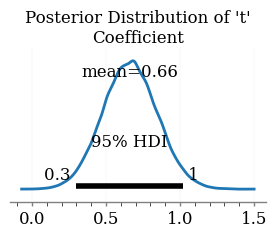

In [55]:
import arviz as az

print("\n--- Bambi Model Summary (ArviZ) ---")
# Use ArviZ for a comprehensive summary, including R-hat and ESS diagnostics
print(az.summary(idata, var_names=['~1|uuid', '~1|uuid_sigma'], kind="stats",  hdi_prob=0.95)) # Exclude y_obs for cleaner summary

# Plot the posteriors for key parameters (e.g., 't')
print("\n--- Plotting Posterior Distributions ---")
az.plot_posterior(idata, var_names=['C(t)'], kind='kde', hdi_prob=.95)
plt.title("Posterior Distribution of 't' Coefficient")
plt.show()

# # You can also plot all fixed effects:
# # az.plot_posterior(idata, var_names=[var for var in idata.posterior.data_vars if 'y_obs' not in var and 'uuid' not in var])
# # plt.suptitle("Posterior Distributions of Fixed Effects")
# # plt.tight_layout()
# # plt.show()

# # --- 6. Interpret Results (Manual Extraction) ---
# # Extract mean and 95% HDI (Highest Density Interval) for 't'
# t_posterior_mean = idata.posterior['C(t)'].mean().item()
# hdi = az.hdi(idata, var_names=['C(t)'], hdi_prob=.94)
# t_hdi_lower = hdi['hdi'][0]
# t_hdi_upper = hdi['hdi'][1]

# t_odds_ratio_mean = np.exp(t_posterior_mean)
# t_odds_ratio_hdi_lower = np.exp(t_hdi_lower)
# t_odds_ratio_hdi_upper = np.exp(t_hdi_upper)

# print(f"\n--- Causal Effect of 't' (Non-Random vs. Random) - Bambi Bayesian Model ---")
# print(f"Posterior Mean for 't' coefficient (log-odds): {t_posterior_mean:.4f}")
# print(f"95% HDI for 't' coefficient (log-odds): [{t_hdi_lower:.4f}, {t_hdi_upper:.4f}]")
# print(f"Posterior Mean for 't' Odds Ratio: {t_odds_ratio_mean:.4f}")
# print(f"95% HDI for 't' Odds Ratio: [{t_odds_ratio_hdi_lower:.4f}, {t_odds_ratio_hdi_upper:.4f}]")

# # Bayesian interpretation: Does the HDI include 0 (for coefficient) or 1 (for odds ratio)?
# # If the 95% HDI for the coefficient does NOT include 0, it suggests a strong evidence for an effect.
# # If the 95% HDI for the odds ratio does NOT include 1, it suggests a strong evidence for an effect.

# if t_odds_ratio_mean > 1:
#     print(f"On average, non-random (t=1) assignment is associated with {t_odds_ratio_mean:.2f} times higher odds of getting 'y' (right) compared to random (t=0) assignment.")
# else:
#     print(f"On average, non-random (t=1) assignment is associated with {1/t_odds_ratio_mean:.2f} times lower odds of getting 'y' (right) compared to random (t=0) assignment.")

# # You can also access random effects posteriors (e.g., for uuid)
# # print("\nRandom Effects Posterior Means (first 5 for uuid):")
# # random_effects_uuid = idata.posterior['1|uuid'].mean(dim=['chain', 'draw'])
# # print(random_effects_uuid[:5].to_dict())

In [28]:
df_t1 = df_causal.copy()
df_t1['t'] = 1

df_t0 = df_causal.copy()
df_t0['t'] = 0

y_pred_t1 = model.predict(idata=idata, data=df_t1, kind='pps', inplace=False)['posterior_predictive']['y']
y_pred_t0 = model.predict(idata=idata, data=df_t0, kind='pps', inplace=False)['posterior_predictive']['y']

ate_posterior = (y_pred_t1 - y_pred_t0)

ate_mean = ate_posterior.mean().item()
ate_mean

0.07433997844827586

In [59]:
frm = ("y ~ C(t) + "
       "C(is_pt) + "
       "C(practical_experience) + "
       "C(formal_experience) +"
       "C(knows_ai_music) + "
       "C(choice_type) + "
       "uuid_order +"
       "time_spent + "
       "age "
       # "(1|uuid)"
)

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri

# Load necessary R packages
base = importr('base')
lme4 = importr('lme4')

# Convert pandas DataFrame to R
with localconverter(ro.default_converter + pandas2ri.converter):
    r_df = ro.conversion.py2rpy(df_causal)

# Assign to R global environment
ro.globalenv['df'] = r_df

# Fit logistic mixed model in R
ro.r(f'''
model <- glm(
  {frm},
  data = df,
  family = binomial(link = "logit")
)
''')

# Print model summary
summary = ro.r('summary(model)')
print(summary)




Call:
glm(formula = y ~ C(t) + C(is_pt) + C(practical_experience) + 
    C(formal_experience) + C(knows_ai_music) + C(choice_type) + 
    uuid_order + time_spent + age, family = binomial(link = "logit"), 
    data = df)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -2.138e+01  1.168e+03  -0.018 0.985391    
C(t)1                     5.824e-01  1.677e-01   3.474 0.000513 ***
C(is_pt)TRUE             -1.244e-01  2.092e-01  -0.595 0.551909    
C(practical_experience)1  3.836e-01  2.288e-01   1.677 0.093576 .  
C(practical_experience)2  8.397e-01  4.747e-01   1.769 0.076916 .  
C(practical_experience)3  1.024e+00  3.249e-01   3.152 0.001619 ** 
C(formal_experience)1    -1.810e-01  2.707e-01  -0.669 0.503664    
C(formal_experience)2    -9.898e-01  4.160e-01  -2.379 0.017337 *  
C(formal_experience)3    -6.305e-01  3.797e-01  -1.660 0.096817 .  
C(knows_ai_music)TRUE     7.811e-01  1.875e-01   4.166  3.1e-05 ***
C(choice_type)1 